# 02 — Leakage-Safe EDA and Temporal Split

All modeling decisions in this notebook must use the training period only.

Split contract:

- Train: month 0–4
- Calibration: month 5
- Validation: month 6
- Test: month 7

The test period is reserved for final evaluation.

In [1]:
from pathlib import Path

import pandas as pd
import yaml

from fraudshield.validation import validate_base_dataset


project_root = Path.cwd().resolve()

if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if not (project_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the FraudShield project root.")

config_path = project_root / "configs" / "base.yaml"

with config_path.open(encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

data_path = project_root / config["data"]["raw_path"]

data = pd.read_csv(data_path, low_memory=False)
validated_data = validate_base_dataset(data)

target_column = config["data"]["target_column"]
time_column = config["data"]["time_column"]

print(f"Project root    : {project_root}")
print(f"Dataset path   : {data_path}")
print(f"Validated shape: {validated_data.shape}")

Project root    : D:\latihan\fraudshield
Dataset path   : D:\latihan\fraudshield\data\raw\Base.csv
Validated shape: (1000000, 32)


In [2]:
split_periods = {
    "train": tuple(config["split"]["train_periods"]),
    "calibration": tuple(config["split"]["calibration_periods"]),
    "validation": tuple(config["split"]["validation_periods"]),
    "test": tuple(config["split"]["test_periods"]),
}

configured_periods = [
    period
    for periods in split_periods.values()
    for period in periods
]

if len(configured_periods) != len(set(configured_periods)):
    raise ValueError("Temporal split periods overlap.")

observed_periods = set(validated_data[time_column].unique())
expected_periods = set(configured_periods)

if observed_periods != expected_periods:
    raise ValueError(
        "Configured periods do not match observed periods. "
        f"Configured={sorted(expected_periods)}, "
        f"observed={sorted(observed_periods)}."
    )

summary_records = []

for split_name, periods in split_periods.items():
    split_mask = validated_data[time_column].isin(periods)
    split_target = validated_data.loc[split_mask, target_column]

    summary_records.append(
        {
            "split": split_name,
            "periods": ",".join(map(str, periods)),
            "row_count": int(split_mask.sum()),
            "fraud_count": int(split_target.sum()),
            "fraud_rate": float(split_target.mean()),
        }
    )

split_summary = pd.DataFrame(summary_records)

if split_summary["row_count"].sum() != len(validated_data):
    raise ValueError("Temporal splits do not cover the full dataset.")

print(
    split_summary.to_string(
        index=False,
        formatters={
            "fraud_rate": lambda value: f"{value:.6%}",
        },
    )
)


      split   periods  row_count  fraud_count fraud_rate
      train 0,1,2,3,4     675666         6740  0.997534%
calibration         5     119323         1411  1.182505%
 validation         6     108168         1450  1.340507%
       test         7      96843         1428  1.474552%


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.ticker import PercentFormatter

from fraudshield.data import (
    load_base_dataset,
    select_model_features,
    temporal_split,
)


project_root = Path.cwd().resolve()

if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

if not (project_root / "pyproject.toml").exists():
    raise FileNotFoundError("Could not locate the FraudShield project root.")

config_path = project_root / "configs" / "base.yaml"

with config_path.open(encoding="utf-8") as config_file:
    config = yaml.safe_load(config_file)

data_path = project_root / config["data"]["raw_path"]

sns.set_theme(style="whitegrid")

print(f"Project root : {project_root}")
print(f"Config path  : {config_path}")
print(f"Dataset path : {data_path}")

Project root : D:\latihan\fraudshield
Config path  : D:\latihan\fraudshield\configs\base.yaml
Dataset path : D:\latihan\fraudshield\data\raw\Base.csv


Checkpoint 2.3

Load dan split menggunakan production function

In [5]:
raw_data = load_base_dataset(
    data_path,
    validate=True,
)

split_config = config["split"]
time_column = config["data"]["time_column"]
target_column = config["data"]["target_column"]

splits = temporal_split(
    raw_data,
    time_column=time_column,
    train_periods=split_config["train_periods"],
    calibration_periods=split_config["calibration_periods"],
    validation_periods=split_config["validation_periods"],
    test_periods=split_config["test_periods"],
)

split_summary_records = []

for split_name, split_frame in splits.as_dict().items():
    split_summary_records.append(
        {
            "split": split_name,
            "periods": ",".join(
                map(
                    str,
                    sorted(split_frame[time_column].unique()),
                )
            ),
            "row_count": len(split_frame),
        }
    )

split_summary = pd.DataFrame(split_summary_records)

print(split_summary.to_string(index=False))
print(f"\nTotal rows: {splits.total_rows:,}")

del raw_data

      split   periods  row_count
      train 0,1,2,3,4     675666
calibration         5     119323
 validation         6     108168
       test         7      96843

Total rows: 1,000,000


Terapkan feature exclusion

In [6]:
excluded_columns = config["feature_policy"]["excluded_from_model"]

train_data = splits.train
train_target = train_data[target_column].copy()

train_features = select_model_features(
    train_data,
    excluded_columns=excluded_columns,
)

unexpected_columns = sorted(
    set(excluded_columns) & set(train_features.columns)
)

if unexpected_columns:
    raise ValueError(
        f"Excluded columns remain in predictors: {unexpected_columns}"
    )

print(f"Train shape          : {train_data.shape}")
print(f"Train feature shape  : {train_features.shape}")
print(f"Primary feature count: {train_features.shape[1]}")
print(f"Excluded columns     : {excluded_columns}")

Train shape          : (675666, 32)
Train feature shape  : (675666, 27)
Primary feature count: 27
Excluded columns     : ['fraud_bool', 'month', 'device_fraud_count', 'days_since_request', 'credit_risk_score']


Analisis class imbalance pada train

In [7]:
target_distribution = (
    train_target.value_counts()
    .sort_index()
    .rename_axis("target_value")
    .reset_index(name="row_count")
)

target_distribution["percentage"] = (
    target_distribution["row_count"]
    .div(len(train_target))
    .mul(100)
)

non_fraud_count = int(
    target_distribution.loc[
        target_distribution["target_value"] == 0,
        "row_count",
    ].iloc[0]
)

fraud_count = int(
    target_distribution.loc[
        target_distribution["target_value"] == 1,
        "row_count",
    ].iloc[0]
)

imbalance_ratio = non_fraud_count / fraud_count

print(
    target_distribution.to_string(
        index=False,
        formatters={
            "percentage": lambda value: f"{value:.6f}%",
        },
    )
)

print(
    f"\nNon-fraud to fraud ratio: "
    f"{imbalance_ratio:.2f}:1"
)

 target_value  row_count percentage
            0     668926 99.002466%
            1       6740  0.997534%

Non-fraud to fraud ratio: 99.25:1


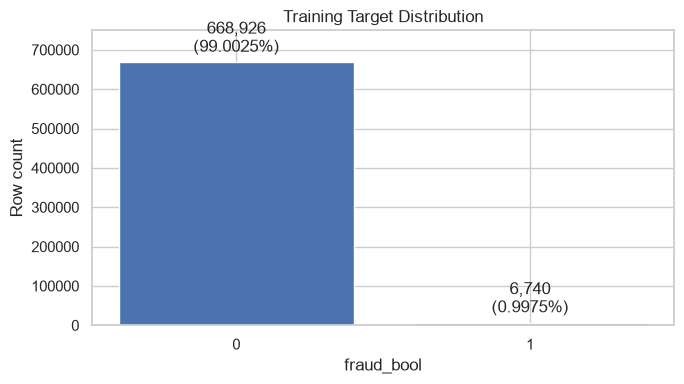

In [8]:
figure, axis = plt.subplots(figsize=(7, 4))

bars = axis.bar(
    target_distribution["target_value"].astype(str),
    target_distribution["row_count"],
)

axis.bar_label(
    bars,
    labels=[
        f"{row_count:,}\n({percentage:.4f}%)"
        for row_count, percentage in zip(
            target_distribution["row_count"],
            target_distribution["percentage"],
            strict=True,
        )
    ],
    padding=4,
)

axis.set_title("Training Target Distribution")
axis.set_xlabel("fraud_bool")
axis.set_ylabel("Row count")
axis.set_ylim(
    0,
    target_distribution["row_count"].max() * 1.12,
)

plt.tight_layout()
plt.show()

Analisis fraud rate per training month

In [9]:
train_temporal_summary = (
    train_data.groupby(time_column, observed=True)
    .agg(
        row_count=(target_column, "size"),
        fraud_count=(target_column, "sum"),
        fraud_rate=(target_column, "mean"),
    )
    .reset_index()
)

print(
    train_temporal_summary.to_string(
        index=False,
        formatters={
            "fraud_rate": lambda value: f"{value:.6%}",
        },
    )
)

 month  row_count  fraud_count fraud_rate
     0     132440         1500  1.132588%
     1     127620         1198  0.938724%
     2     136979         1198  0.874587%
     3     150936         1392  0.922245%
     4     127691         1452  1.137120%


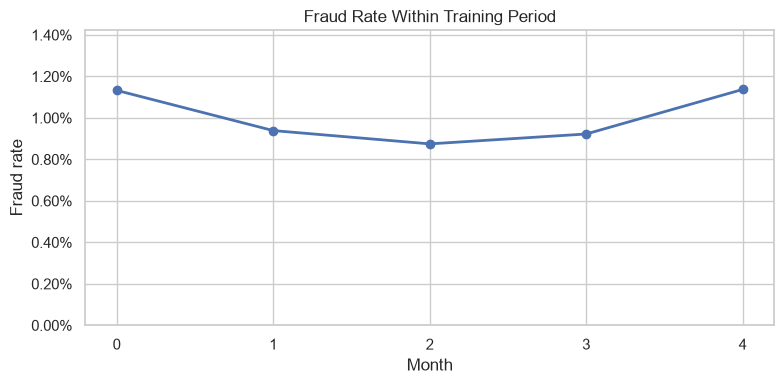

In [10]:
figure, axis = plt.subplots(figsize=(8, 4))

axis.plot(
    train_temporal_summary[time_column],
    train_temporal_summary["fraud_rate"],
    marker="o",
    linewidth=2,
)

axis.set_title("Fraud Rate Within Training Period")
axis.set_xlabel("Month")
axis.set_ylabel("Fraud rate")
axis.set_xticks(train_temporal_summary[time_column])
axis.set_ylim(
    0,
    train_temporal_summary["fraud_rate"].max() * 1.25,
)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

Audit semantic missing pada train saja

In [11]:
semantic_missing_masks = {
    "prev_address_months_count": (
        train_data["prev_address_months_count"].eq(-1)
    ),
    "current_address_months_count": (
        train_data["current_address_months_count"].eq(-1)
    ),
    "bank_months_count": (
        train_data["bank_months_count"].eq(-1)
    ),
    "session_length_in_minutes": (
        train_data["session_length_in_minutes"].eq(-1)
    ),
    "device_distinct_emails_8w": (
        train_data["device_distinct_emails_8w"].eq(-1)
    ),
    "intended_balcon_amount": (
        train_data["intended_balcon_amount"].lt(0)
    ),
}

semantic_missing_summary = pd.DataFrame(
    [
        {
            "column": column,
            "missing_count": int(mask.sum()),
            "missing_percentage": float(mask.mean() * 100),
        }
        for column, mask in semantic_missing_masks.items()
    ]
).sort_values(
    "missing_percentage",
    ascending=False,
    ignore_index=True,
)

print(
    semantic_missing_summary.to_string(
        index=False,
        formatters={
            "missing_percentage": lambda value: f"{value:.4f}%",
        },
    )
)

                      column  missing_count missing_percentage
      intended_balcon_amount         493751           73.0762%
   prev_address_months_count         469907           69.5472%
           bank_months_count         172287           25.4988%
current_address_months_count           2827            0.4184%
   session_length_in_minutes           1278            0.1891%
   device_distinct_emails_8w            276            0.0408%


In [ ]:
Periksa jenis predictor

In [12]:
categorical_features = train_features.select_dtypes(
    include=["object", "string", "category"],
).columns.tolist()

numeric_features = train_features.select_dtypes(
    include="number",
).columns.tolist()

if len(categorical_features) + len(numeric_features) != len(
    train_features.columns
):
    raise ValueError("Some feature dtypes were not classified.")

print(f"Categorical feature count: {len(categorical_features)}")
print(f"Numeric feature count    : {len(numeric_features)}")
print(f"Total feature count      : {train_features.shape[1]}")
print(f"\nCategorical features     : {categorical_features}")

Categorical feature count: 5
Numeric feature count    : 22
Total feature count      : 27

Categorical features     : ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


Checkpoint 2.4A

In [ ]:
Profil kategori training

In [13]:
categorical_profile_records = []

for column in categorical_features:
    category_counts = (
        train_data[column]
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="row_count")
    )

    category_counts["percentage"] = (
        category_counts["row_count"]
        .div(len(train_data))
        .mul(100)
    )

    for record in category_counts.to_dict(orient="records"):
        categorical_profile_records.append(
            {
                "column": column,
                **record,
            }
        )

categorical_profile = pd.DataFrame(
    categorical_profile_records
).sort_values(
    ["column", "row_count"],
    ascending=[True, False],
    ignore_index=True,
)

category_coverage = categorical_profile.groupby(
    "column",
    observed=True,
)["row_count"].sum()

if not category_coverage.eq(len(train_data)).all():
    raise ValueError("Categorical profile does not cover all training rows.")

print(
    categorical_profile.to_string(
        index=False,
        formatters={
            "percentage": lambda value: f"{value:.4f}%",
        },
    )
)

           column  category  row_count percentage
        device_os     linux     232252   34.3738%
        device_os     other     220215   32.5923%
        device_os   windows     182429   26.9999%
        device_os macintosh      35809    5.2998%
        device_os       x11       4961    0.7342%
employment_status        CA     480770   71.1550%
employment_status        CB     102251   15.1334%
employment_status        CF      30444    4.5058%
employment_status        CC      27614    4.0869%
employment_status        CD      19680    2.9127%
employment_status        CE      14581    2.1580%
employment_status        CG        326    0.0482%
   housing_status        BC     262914   38.9118%
   housing_status        BB     171639   25.4029%
   housing_status        BE     115214   17.0519%
   housing_status        BA     110423   16.3428%
   housing_status        BD      14074    2.0830%
   housing_status        BF       1201    0.1778%
   housing_status        BG        201    0.0297%


Deteksi rare categories

In [14]:
rare_category_threshold = 1.0

rare_categories = categorical_profile.loc[
    categorical_profile["percentage"] < rare_category_threshold
].copy()

print(
    rare_categories.to_string(
        index=False,
        formatters={
            "percentage": lambda value: f"{value:.4f}%",
        },
    )
)

print(
    f"\nRare categories below "
    f"{rare_category_threshold:.1f}%: "
    f"{len(rare_categories)}"
)

           column category  row_count percentage
        device_os      x11       4961    0.7342%
employment_status       CG        326    0.0482%
   housing_status       BF       1201    0.1778%
   housing_status       BG        201    0.0297%
     payment_type       AE        236    0.0349%
           source  TELEAPP       5070    0.7504%

Rare categories below 1.0%: 6


Fraud rate per kategori

In [15]:
categorical_target_records = []

for column in categorical_features:
    column_summary = (
        train_data.groupby(
            column,
            observed=True,
            dropna=False,
        )
        .agg(
            row_count=(target_column, "size"),
            fraud_count=(target_column, "sum"),
            fraud_rate=(target_column, "mean"),
        )
        .reset_index()
        .rename(columns={column: "category"})
    )

    column_summary.insert(0, "column", column)

    categorical_target_records.extend(
        column_summary.to_dict(orient="records")
    )

categorical_target_summary = pd.DataFrame(
    categorical_target_records
).sort_values(
    ["column", "fraud_rate"],
    ascending=[True, False],
    ignore_index=True,
)

print(
    categorical_target_summary.to_string(
        index=False,
        formatters={
            "fraud_rate": lambda value: f"{value:.6%}",
        },
    )
)

           column  category  row_count  fraud_count fraud_rate
        device_os   windows     182429         4096  2.245257%
        device_os macintosh      35809          431  1.203608%
        device_os       x11       4961           53  1.068333%
        device_os     other     220215         1150  0.522217%
        device_os     linux     232252         1010  0.434872%
employment_status        CC      27614          637  2.306801%
employment_status        CG        326            4  1.226994%
employment_status        CA     480770         5309  1.104270%
employment_status        CB     102251          626  0.612219%
employment_status        CD      19680           76  0.386179%
employment_status        CE      14581           33  0.226322%
employment_status        CF      30444           55  0.180660%
   housing_status        BA     110423         3778  3.421389%
   housing_status        BD      14074          121  0.859741%
   housing_status        BC     262914         1496  0.

Numeric summary

In [16]:
numeric_summary = (
    train_features[numeric_features]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .transpose()
    .rename(
        columns={
            "1%": "p01",
            "5%": "p05",
            "25%": "p25",
            "50%": "median",
            "75%": "p75",
            "95%": "p95",
            "99%": "p99",
        }
    )
)

numeric_summary["nunique"] = (
    train_features[numeric_features].nunique()
)

numeric_summary = numeric_summary[
    [
        "count",
        "nunique",
        "mean",
        "std",
        "min",
        "p01",
        "p05",
        "p25",
        "median",
        "p75",
        "p95",
        "p99",
        "max",
    ]
]

print(numeric_summary.round(4).to_string())

                                     count  nunique       mean        std        min        p01        p05        p25     median        p75         p95         p99         max
income                            675666.0        9     0.5416     0.2925     0.1000     0.1000     0.1000     0.3000     0.6000     0.8000      0.9000      0.9000      0.9000
name_email_similarity             675666.0   675117     0.5034     0.2913     0.0000     0.0196     0.0630     0.2348     0.5063     0.7677      0.9209      0.9975      1.0000
prev_address_months_count         675666.0      369    17.4525    45.0207    -1.0000    -1.0000    -1.0000    -1.0000    -1.0000    20.0000     99.0000    236.0000    377.0000
current_address_months_count      675666.0      421    86.8164    90.8475    -1.0000     0.0000     3.0000    18.0000    51.0000   131.0000    289.0000    371.0000    425.0000
customer_age                      675666.0        9    33.6839    12.0954    10.0000    10.0000    20.0000    20.0000   

Pisahkan numeric continuous dan discrete

In [17]:
numeric_cardinality = (
    train_features[numeric_features]
    .nunique()
    .sort_values()
)

discrete_numeric_features = numeric_cardinality.loc[
    numeric_cardinality <= 10
].index.tolist()

continuous_numeric_features = numeric_cardinality.loc[
    numeric_cardinality > 10
].index.tolist()

print(
    f"Discrete numeric features  : "
    f"{len(discrete_numeric_features)}"
)
print(
    f"Continuous numeric features: "
    f"{len(continuous_numeric_features)}"
)

print(
    "\nDiscrete numeric features:\n",
    discrete_numeric_features,
)

print(
    "\nContinuous numeric features:\n",
    continuous_numeric_features,
)

Discrete numeric features  : 9
Continuous numeric features: 13

Discrete numeric features:
 ['phone_mobile_valid', 'email_is_free', 'phone_home_valid', 'has_other_cards', 'foreign_request', 'keep_alive_session', 'device_distinct_emails_8w', 'income', 'customer_age']

Continuous numeric features:
 ['proposed_credit_limit', 'bank_months_count', 'date_of_birth_distinct_emails_4w', 'prev_address_months_count', 'current_address_months_count', 'bank_branch_count_8w', 'zip_count_4w', 'session_length_in_minutes', 'intended_balcon_amount', 'velocity_4w', 'velocity_6h', 'name_email_similarity', 'velocity_24h']


Korelasi linear numeric dengan target

In [19]:
numeric_target_correlations = (
    train_data[
        [
            *numeric_features,
            target_column,
        ]
    ]
    .corr(numeric_only=True)[target_column]
    .drop(labels=target_column)
    .sort_values(
        key=lambda series: series.abs(),
        ascending=False,
    )
    .rename_axis("feature")
    .reset_index(name="correlation")
)

print(
    numeric_target_correlations.head(10).to_string(
        index=False,
        formatters={
            "correlation": lambda value: f"{value:.6f}",
        },
    )
)

                         feature correlation
           proposed_credit_limit    0.064481
                    customer_age    0.063929
              keep_alive_session   -0.048539
date_of_birth_distinct_emails_4w   -0.043870
                          income    0.042584
       device_distinct_emails_8w    0.035844
    current_address_months_count    0.034381
           name_email_similarity   -0.034317
                 has_other_cards   -0.031986
                phone_home_valid   -0.028883


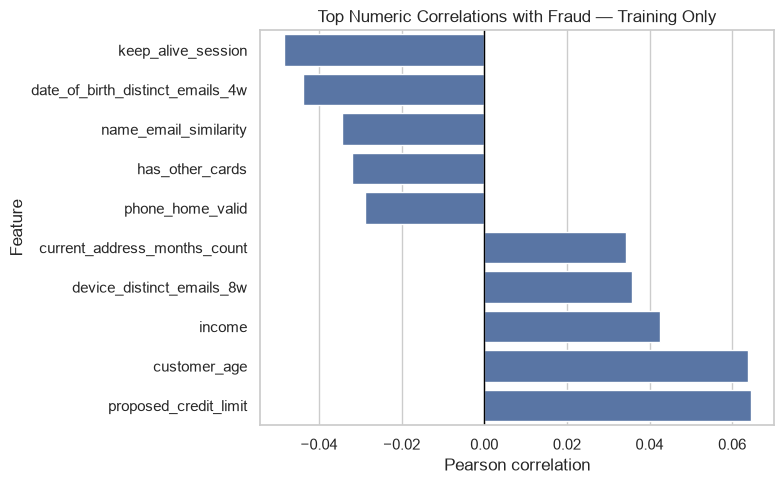

In [20]:
top_numeric_correlations = (
    numeric_target_correlations
    .head(10)
    .sort_values("correlation")
)

figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top_numeric_correlations,
    x="correlation",
    y="feature",
    ax=axis,
)

axis.axvline(
    0,
    color="black",
    linewidth=1,
)

axis.set_title(
    "Top Numeric Correlations with Fraud — Training Only"
)
axis.set_xlabel("Pearson correlation")
axis.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
print("=== RARE CATEGORIES BELOW 1% ===")
print(
    rare_categories.to_string(
        index=False,
        formatters={
            "percentage": lambda value: f"{value:.4f}%",
        },
    )
)

print("\n=== CATEGORICAL FRAUD RATE ===")
print(
    categorical_target_summary.to_string(
        index=False,
        formatters={
            "fraud_rate": lambda value: f"{value:.6%}",
        },
    )
)

print("\n=== NUMERIC FEATURE GROUPS ===")
print(
    f"Discrete numeric ({len(discrete_numeric_features)}):"
)
print(discrete_numeric_features)

print(
    f"\nContinuous numeric "
    f"({len(continuous_numeric_features)}):"
)
print(continuous_numeric_features)

print("\n=== TOP 10 NUMERIC TARGET CORRELATIONS ===")
print(
    numeric_target_correlations.head(10).to_string(
        index=False,
        formatters={
            "correlation": lambda value: f"{value:.6f}",
        },
    )
)

=== RARE CATEGORIES BELOW 1% ===
           column category  row_count percentage
        device_os      x11       4961    0.7342%
employment_status       CG        326    0.0482%
   housing_status       BF       1201    0.1778%
   housing_status       BG        201    0.0297%
     payment_type       AE        236    0.0349%
           source  TELEAPP       5070    0.7504%

=== CATEGORICAL FRAUD RATE ===
           column  category  row_count  fraud_count fraud_rate
        device_os   windows     182429         4096  2.245257%
        device_os macintosh      35809          431  1.203608%
        device_os       x11       4961           53  1.068333%
        device_os     other     220215         1150  0.522217%
        device_os     linux     232252         1010  0.434872%
employment_status        CC      27614          637  2.306801%
employment_status        CG        326            4  1.226994%
employment_status        CA     480770         5309  1.104270%
employment_status        

In [22]:
print("=== RARE CATEGORIES ===")

for row in rare_categories.itertuples(index=False):
    print(
        f"{row.column}={row.category}: "
        f"{row.row_count:,} rows "
        f"({row.percentage:.4f}%)"
    )

print("\n=== SUPPORTED HIGH-RISK CATEGORIES ===")

supported_category_rates = (
    categorical_target_summary.loc[
        categorical_target_summary["row_count"] >= 1_000
    ]
    .sort_values(
        ["column", "fraud_rate"],
        ascending=[True, False],
    )
    .groupby("column", observed=True)
    .head(3)
)

for row in supported_category_rates.itertuples(index=False):
    print(
        f"{row.column}={row.category}: "
        f"rows={row.row_count:,}, "
        f"fraud_rate={row.fraud_rate:.6%}"
    )

print("\n=== DISCRETE NUMERIC FEATURES ===")
print(", ".join(discrete_numeric_features))

print("\n=== CONTINUOUS NUMERIC FEATURES ===")
print(", ".join(continuous_numeric_features))

print("\n=== TOP 10 NUMERIC CORRELATIONS ===")

for row in numeric_target_correlations.head(10).itertuples(
    index=False
):
    print(
        f"{row.feature}: "
        f"{row.correlation:.6f}"
    )

=== RARE CATEGORIES ===
device_os=x11: 4,961 rows (0.7342%)
employment_status=CG: 326 rows (0.0482%)
housing_status=BF: 1,201 rows (0.1778%)
housing_status=BG: 201 rows (0.0297%)
payment_type=AE: 236 rows (0.0349%)
source=TELEAPP: 5,070 rows (0.7504%)

=== SUPPORTED HIGH-RISK CATEGORIES ===
device_os=windows: rows=182,429, fraud_rate=2.245257%
device_os=macintosh: rows=35,809, fraud_rate=1.203608%
device_os=x11: rows=4,961, fraud_rate=1.068333%
employment_status=CC: rows=27,614, fraud_rate=2.306801%
employment_status=CA: rows=480,770, fraud_rate=1.104270%
employment_status=CB: rows=102,251, fraud_rate=0.612219%
housing_status=BA: rows=110,423, fraud_rate=3.421389%
housing_status=BD: rows=14,074, fraud_rate=0.859741%
housing_status=BC: rows=262,914, fraud_rate=0.569007%
payment_type=AC: rows=171,511, fraud_rate=1.520019%
payment_type=AB: rows=235,411, fraud_rate=1.015246%
payment_type=AD: rows=87,209, fraud_rate=0.934537%
source=TELEAPP: rows=5,070, fraud_rate=1.439842%
source=INTERNET:

Checkpoint 2.4B

1. Tambahkan NumPy

In [23]:
import numpy as np

2. Buat fungsi PSI

In [24]:
def categorical_psi(
    reference: pd.Series,
    current: pd.Series,
    *,
    epsilon: float = 1e-6,
) -> float:
    """Calculate PSI for categorical or discrete values."""
    reference_values = (
        reference.astype("string")
        .fillna("<MISSING>")
    )
    current_values = (
        current.astype("string")
        .fillna("<MISSING>")
    )

    reference_proportions = (
        reference_values.value_counts(normalize=True)
    )
    current_proportions = (
        current_values.value_counts(normalize=True)
    )

    categories = reference_proportions.index.union(
        current_proportions.index
    )

    reference_proportions = (
        reference_proportions
        .reindex(categories, fill_value=0.0)
        .clip(lower=epsilon)
    )
    current_proportions = (
        current_proportions
        .reindex(categories, fill_value=0.0)
        .clip(lower=epsilon)
    )

    psi_values = (
        current_proportions - reference_proportions
    ) * np.log(
        current_proportions / reference_proportions
    )

    return float(psi_values.sum())


def numeric_psi(
    reference: pd.Series,
    current: pd.Series,
    *,
    number_of_bins: int = 10,
    epsilon: float = 1e-6,
) -> float:
    """Calculate quantile-based PSI using reference-period bins."""
    reference_values = pd.to_numeric(
        reference,
        errors="coerce",
    ).dropna()

    current_values = pd.to_numeric(
        current,
        errors="coerce",
    ).dropna()

    if reference_values.empty or current_values.empty:
        raise ValueError("PSI input must contain numeric values.")

    quantiles = np.linspace(
        0,
        1,
        number_of_bins + 1,
    )

    bin_edges = np.unique(
        reference_values.quantile(quantiles).to_numpy()
    )

    if len(bin_edges) < 3:
        return categorical_psi(reference, current)

    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    reference_bins = pd.cut(
        reference_values,
        bins=bin_edges,
        include_lowest=True,
        duplicates="drop",
    )
    current_bins = pd.cut(
        current_values,
        bins=bin_edges,
        include_lowest=True,
        duplicates="drop",
    )

    reference_proportions = (
        reference_bins.value_counts(
            sort=False,
            normalize=True,
        )
    )
    current_proportions = (
        current_bins.value_counts(
            sort=False,
            normalize=True,
        )
        .reindex(
            reference_proportions.index,
            fill_value=0.0,
        )
    )

    reference_array = np.clip(
        reference_proportions.to_numpy(),
        epsilon,
        None,
    )
    current_array = np.clip(
        current_proportions.to_numpy(),
        epsilon,
        None,
    )

    psi_values = (
        current_array - reference_array
    ) * np.log(
        current_array / reference_array
    )

    return float(psi_values.sum())

3. Hitung PSI month 0 versus month 4

In [25]:
reference_month = 0
comparison_month = 4

reference_data = train_data.loc[
    train_data[time_column] == reference_month
]

comparison_data = train_data.loc[
    train_data[time_column] == comparison_month
]

psi_records = []

for feature in train_features.columns:
    if feature in continuous_numeric_features:
        feature_psi = numeric_psi(
            reference_data[feature],
            comparison_data[feature],
        )
        psi_method = "quantile"
    else:
        feature_psi = categorical_psi(
            reference_data[feature],
            comparison_data[feature],
        )
        psi_method = "categorical"

    if feature_psi < 0.10:
        drift_level = "low"
    elif feature_psi < 0.25:
        drift_level = "moderate"
    else:
        drift_level = "high"

    psi_records.append(
        {
            "feature": feature,
            "psi": feature_psi,
            "drift_level": drift_level,
            "method": psi_method,
        }
    )

psi_summary = pd.DataFrame(
    psi_records
).sort_values(
    "psi",
    ascending=False,
    ignore_index=True,
)

print(
    psi_summary.to_string(
        index=False,
        formatters={
            "psi": lambda value: f"{value:.6f}",
        },
    )
)

                         feature      psi drift_level      method
                     velocity_4w 5.489757        high    quantile
                    velocity_24h 1.267608        high    quantile
                     velocity_6h 0.639067        high    quantile
                    zip_count_4w 0.383717        high    quantile
date_of_birth_distinct_emails_4w 0.265354        high    quantile
                    payment_type 0.201218    moderate categorical
              keep_alive_session 0.161731    moderate categorical
            bank_branch_count_8w 0.132547    moderate    quantile
               employment_status 0.097490         low categorical
               bank_months_count 0.081788         low    quantile
           name_email_similarity 0.079210         low    quantile
          intended_balcon_amount 0.069241         low    quantile
           proposed_credit_limit 0.068170         low    quantile
                  housing_status 0.045800         low categorical
       ses

4. Tampilkan ringkasan pendek

In [26]:
print("=== TOP 15 PSI: MONTH 0 VS MONTH 4 ===")

for row in psi_summary.head(15).itertuples(index=False):
    print(
        f"{row.feature}: "
        f"PSI={row.psi:.6f}, "
        f"level={row.drift_level}, "
        f"method={row.method}"
    )

print("\n=== DRIFT LEVEL COUNTS ===")
print(
    psi_summary["drift_level"]
    .value_counts()
    .to_string()
)

=== TOP 15 PSI: MONTH 0 VS MONTH 4 ===
velocity_4w: PSI=5.489757, level=high, method=quantile
velocity_24h: PSI=1.267608, level=high, method=quantile
velocity_6h: PSI=0.639067, level=high, method=quantile
zip_count_4w: PSI=0.383717, level=high, method=quantile
date_of_birth_distinct_emails_4w: PSI=0.265354, level=high, method=quantile
payment_type: PSI=0.201218, level=moderate, method=categorical
keep_alive_session: PSI=0.161731, level=moderate, method=categorical
bank_branch_count_8w: PSI=0.132547, level=moderate, method=quantile
employment_status: PSI=0.097490, level=low, method=categorical
bank_months_count: PSI=0.081788, level=low, method=quantile
name_email_similarity: PSI=0.079210, level=low, method=quantile
intended_balcon_amount: PSI=0.069241, level=low, method=quantile
proposed_credit_limit: PSI=0.068170, level=low, method=quantile
housing_status: PSI=0.045800, level=low, method=categorical
session_length_in_minutes: PSI=0.044192, level=low, method=quantile

=== DRIFT LEVEL CO

5. Buat chart PSI

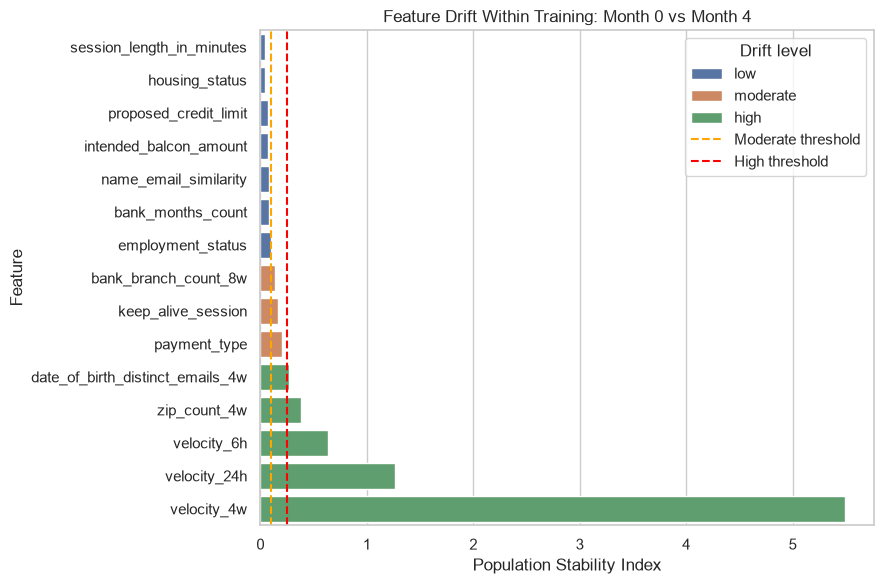

In [27]:
top_psi_features = (
    psi_summary.head(15)
    .sort_values("psi")
)

figure, axis = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=top_psi_features,
    x="psi",
    y="feature",
    hue="drift_level",
    dodge=False,
    ax=axis,
)

axis.axvline(
    0.10,
    color="orange",
    linestyle="--",
    label="Moderate threshold",
)

axis.axvline(
    0.25,
    color="red",
    linestyle="--",
    label="High threshold",
)

axis.set_title(
    "Feature Drift Within Training: Month 0 vs Month 4"
)
axis.set_xlabel("Population Stability Index")
axis.set_ylabel("Feature")
axis.legend(title="Drift level")

plt.tight_layout()
plt.show()

6. Audit perubahan semantic missing

In [28]:
semantic_missing_rules = {
    "prev_address_months_count": lambda series: series.eq(-1),
    "current_address_months_count": lambda series: series.eq(-1),
    "bank_months_count": lambda series: series.eq(-1),
    "session_length_in_minutes": lambda series: series.eq(-1),
    "device_distinct_emails_8w": lambda series: series.eq(-1),
    "intended_balcon_amount": lambda series: series.lt(0),
}

missing_drift_records = []

for column, missing_rule in semantic_missing_rules.items():
    reference_missing_rate = float(
        missing_rule(reference_data[column]).mean()
    )
    comparison_missing_rate = float(
        missing_rule(comparison_data[column]).mean()
    )

    missing_drift_records.append(
        {
            "column": column,
            "month_0_missing_rate": reference_missing_rate,
            "month_4_missing_rate": comparison_missing_rate,
            "absolute_change": abs(
                comparison_missing_rate
                - reference_missing_rate
            ),
        }
    )

missing_drift_summary = pd.DataFrame(
    missing_drift_records
).sort_values(
    "absolute_change",
    ascending=False,
    ignore_index=True,
)

print(
    missing_drift_summary.to_string(
        index=False,
        formatters={
            "month_0_missing_rate": (
                lambda value: f"{value:.4%}"
            ),
            "month_4_missing_rate": (
                lambda value: f"{value:.4%}"
            ),
            "absolute_change": (
                lambda value: f"{value:.4%}"
            ),
        },
    )
)

                      column month_0_missing_rate month_4_missing_rate absolute_change
           bank_months_count             13.3925%             27.7177%        14.3252%
      intended_balcon_amount             69.5017%             78.7299%         9.2282%
   prev_address_months_count             70.0257%             72.3230%         2.2974%
current_address_months_count              0.4606%              0.4057%         0.0549%
   session_length_in_minutes              0.1767%              0.2216%         0.0449%
   device_distinct_emails_8w              0.0279%              0.0392%         0.0112%


In [ ]:
Checkpoint 2.4C — Sanity check drift

In [29]:
from itertools import pairwise

1. PSI antar-month berturut-turut

In [30]:
high_drift_features = psi_summary.loc[
    psi_summary["drift_level"] == "high",
    "feature",
].tolist()

training_months = sorted(
    train_data[time_column].unique().tolist()
)

consecutive_psi_records = []

for previous_month, current_month in pairwise(training_months):
    previous_data = train_data.loc[
        train_data[time_column] == previous_month
    ]
    current_data = train_data.loc[
        train_data[time_column] == current_month
    ]

    for feature in high_drift_features:
        if feature in continuous_numeric_features:
            feature_psi = numeric_psi(
                previous_data[feature],
                current_data[feature],
            )
        else:
            feature_psi = categorical_psi(
                previous_data[feature],
                current_data[feature],
            )

        consecutive_psi_records.append(
            {
                "transition": (
                    f"{previous_month}->{current_month}"
                ),
                "feature": feature,
                "psi": feature_psi,
            }
        )

consecutive_psi = pd.DataFrame(
    consecutive_psi_records
)

consecutive_psi_pivot = consecutive_psi.pivot(
    index="feature",
    columns="transition",
    values="psi",
).loc[high_drift_features]

print(
    consecutive_psi_pivot.to_string(
        formatters={
            column: lambda value: f"{value:.6f}"
            for column in consecutive_psi_pivot.columns
        }
    )
)

transition                           0->1     1->2     2->3     3->4
feature                                                             
velocity_4w                      3.942928 0.510658 3.045433 0.961126
velocity_24h                     0.232104 0.083656 0.268245 0.171036
velocity_6h                      0.165658 0.019826 0.102870 0.090590
zip_count_4w                     0.221048 0.011397 0.053708 0.025106
date_of_birth_distinct_emails_4w 0.088919 0.013121 0.083733 0.010313


2. Distribusi bulanan high-drift features

In [31]:
monthly_distribution_records = []

for month in training_months:
    month_data = train_data.loc[
        train_data[time_column] == month
    ]

    for feature in high_drift_features:
        feature_values = month_data[feature]

        monthly_distribution_records.append(
            {
                "month": month,
                "feature": feature,
                "mean": float(feature_values.mean()),
                "median": float(feature_values.median()),
                "p05": float(feature_values.quantile(0.05)),
                "p95": float(feature_values.quantile(0.95)),
            }
        )

monthly_high_drift_summary = pd.DataFrame(
    monthly_distribution_records
)

for feature in high_drift_features:
    print(f"\n=== {feature} ===")

    feature_summary = monthly_high_drift_summary.loc[
        monthly_high_drift_summary["feature"] == feature,
        [
            "month",
            "mean",
            "median",
            "p05",
            "p95",
        ],
    ]

    print(
        feature_summary.round(4).to_string(
            index=False
        )
    )


=== velocity_4w ===
 month      mean    median       p05       p95
     0 6189.1826 6343.5905 4836.3663 6796.8873
     1 5392.2240 5446.3239 4734.8368 5924.6917
     2 5356.3023 5462.1672 4855.2253 5707.9874
     3 4913.6003 4909.9276 4353.6642 5234.0400
     4 4640.1677 4695.6586 4168.1950 5162.8187

=== velocity_24h ===
 month      mean    median       p05       p95
     0 5882.4096 5950.3692 3747.1027 7658.6718
     1 5544.7458 5340.6613 3360.4077 7944.4803
     2 5293.5354 5044.8226 3395.8410 7689.3495
     3 4972.6254 4969.4455 3172.9537 6953.4262
     4 4612.5848 4662.3402 2883.9524 6356.2215

=== velocity_6h ===
 month      mean    median       p05        p95
     0 7436.9803 7623.0456 2077.1514 12682.0475
     1 6821.4101 6482.0670 1731.7234 12799.5636
     2 6465.4104 6164.5073 1592.6092 12289.7781
     3 5960.1574 5940.0989 1357.6710 10174.3803
     4 5323.3320 5242.3244 1299.3706  9375.5769

=== zip_count_4w ===
 month      mean  median   p05    p95
     0 2168.8304  1702.0

3. kesimpulan notebook

## Leakage-Safe EDA Decisions

### Temporal split

- Train: month 0–4.
- Calibration: month 5.
- Validation: month 6.
- Test: month 7.
- Test features and target are not used for EDA or modeling decisions.

### Class imbalance

The training fraud rate is 0.9975%, equivalent to approximately 99.25
non-fraud applications for every fraud application.

Accuracy will not be used as the primary model-selection metric.

### Categorical features

Rare categories are retained. Preprocessing must support unknown categories
without learning category rules from calibration, validation, or test data.

Observed category-level fraud-rate differences are associations and are not
interpreted as causal effects.

### Semantic missing values

Semantic sentinel values will be converted to missing values inside the
preprocessing pipeline.

Missing indicators are required because missingness is common and changes over
time, particularly for:

- `bank_months_count`
- `intended_balcon_amount`
- `prev_address_months_count`

Imputation statistics must be learned from training data only.

### Temporal drift

Month 0 versus month 4 PSI identified high drift in:

- `velocity_4w`
- `velocity_24h`
- `velocity_6h`
- `zip_count_4w`
- `date_of_birth_distinct_emails_4w`

Moderate drift was detected in:

- `payment_type`
- `keep_alive_session`
- `bank_branch_count_8w`

High-drift features are not removed solely based on PSI. They will be retained
for the baseline and evaluated through temporal validation and feature-ablation
experiments.

### Primary feature policy

The primary model excludes:

- `fraud_bool`
- `month`
- `device_fraud_count`
- `days_since_request`
- `credit_risk_score`

The primary feature set contains 27 predictors.

### Drift sanity-check conclusion

The high PSI values are supported by changes in the observed monthly
distributions and are not treated as calculation errors.

The velocity features show a general downward trend during the training
period. `velocity_4w` has especially large distribution changes between
month 0–1 and month 2–3.

These features are retained because they represent information expected to be
available at prediction time. However, they are marked as high-drift features
and must be evaluated through:

- Temporal validation.
- Performance-by-period analysis.
- Feature-ablation experiments.
- Production drift monitoring.

No feature is removed solely because of its PSI value.